In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 3")

##  Section 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import joblib, os

In [7]:
# Stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

In [12]:
pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/711.9 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 711.9/711.9 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 4.5 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 3.8 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 4.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.5 MB 4.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 4.8 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.5 MB 4.9 MB/s eta 0:00:01
   --------------------

In [8]:
# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb

In [9]:
# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [10]:
# Prophet
from prophet import Prophet

In [11]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 5.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/12.1 MB 4.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.1 MB 5.1 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.1 MB 5.3 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.1 MB 5.4 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.1 MB 5.5 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/12.1 MB 5.6 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 5.5 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.1 MB 5.4 MB/s eta 0:00:01
   ----------------------------------- ---- 10.7/12.1 MB 5.3 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.1 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 5.2 MB/s eta 0:00:00
  

In [11]:
os.makedirs('models', exist_ok=True)
os.makedirs('predictions', exist_ok=True)

## Section 2: Load Dataset

In [12]:
# Load dataset 
try:
    df = pd.read_csv('BTC_cleaned.csv', index_col='Date', parse_dates=True)
    print("Loaded cleaned data from Notebook 1")
except FileNotFoundError:
    df = pd.read_csv('BTC-USD.csv', index_col='Date', parse_dates=True)  # UPDATE THIS PATH
    print(" Loaded raw data (will clean in this notebook)")

Loaded cleaned data from Notebook 1


In [13]:
print(f'Loaded: {df.shape}')
df.head()

Loaded: (3566, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2014-10-10,364.687012,375.066986,352.963013,361.562012,43665700.0
2014-10-11,361.362000,367.191010,355.950989,362.299011,13345200.0
2014-10-12,362.605988,379.433014,356.144012,378.549011,17552800.0
2014-10-13,377.920990,397.226013,368.897003,390.414001,35221400.0
2014-10-14,391.691986,411.697998,391.324005,400.869995,38491500.0


## Section 3 : Feature Engineering

In [14]:
d = df.copy()

In [15]:
# ── Moving Averages ──
for w in [7, 14, 21, 30, 50, 100, 200]:
    d[f'MA_{w}'] = d['Close'].rolling(w).mean()

In [16]:
# ── Exponential Moving Averages ──
for span in [9, 12, 26, 50]:
    d[f'EMA_{span}'] = d['Close'].ewm(span=span, adjust=False).mean()

In [17]:
# ── MACD ──
d['MACD']        = d['EMA_12'] - d['EMA_26']
d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']

In [18]:
# ── Bollinger Bands (20-day) ──
d['BB_Mid']   = d['Close'].rolling(20).mean()
d['BB_Std']   = d['Close'].rolling(20).std()
d['BB_Upper'] = d['BB_Mid'] + 2 * d['BB_Std']
d['BB_Lower'] = d['BB_Mid'] - 2 * d['BB_Std']
d['BB_Width'] = (d['BB_Upper'] - d['BB_Lower']) / d['BB_Mid']

In [19]:
# ── RSI (14-day) ──
delta = d['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
d['RSI'] = 100 - (100 / (1 + gain / loss))

In [20]:
# ── Stochastic Oscillator ──
low14  = d['Low'].rolling(14).min()
high14 = d['High'].rolling(14).max()
d['Stoch_K'] = 100 * (d['Close'] - low14) / (high14 - low14)
d['Stoch_D'] = d['Stoch_K'].rolling(3).mean()

In [21]:
# ── Average True Range (ATR) ──
tr1 = d['High'] - d['Low']
tr2 = (d['High'] - d['Close'].shift()).abs()
tr3 = (d['Low']  - d['Close'].shift()).abs()
d['ATR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1).rolling(14).mean()

In [22]:
# ── Rolling Statistics ──
for w in [7, 14, 30]:
    d[f'Roll_Std_{w}']  = d['Close'].rolling(w).std()
    d[f'Roll_Min_{w}']  = d['Close'].rolling(w).min()
    d[f'Roll_Max_{w}']  = d['Close'].rolling(w).max()
    d[f'Roll_Skew_{w}'] = d['Close'].rolling(w).skew()

In [23]:
# ── Price Change Features ──
d['Daily_Return']  = d['Close'].pct_change()
d['Log_Return']    = np.log(d['Close'] / d['Close'].shift(1))
d['Price_Change']  = d['Close'].diff()
d['HL_Spread']     = d['High'] - d['Low']
d['OC_Spread']     = d['Close'] - d['Open']
d['HL_Spread_Pct'] = d['HL_Spread'] / d['Close']

In [24]:
# ── Lag Features ──
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    d[f'Lag_{lag}'] = d['Close'].shift(lag)

In [25]:
# ── Volume Features ──
d['Vol_MA_7']    = d['Volume'].rolling(7).mean()
d['Vol_MA_30']   = d['Volume'].rolling(30).mean()
d['Vol_Change']  = d['Volume'].pct_change()
d['Vol_Ratio']   = d['Volume'] / d['Vol_MA_30']

In [26]:
# ── Date Features ──
d['DayOfWeek']  = d.index.dayofweek
d['DayOfMonth'] = d.index.day
d['DayOfYear']  = d.index.dayofyear
d['WeekOfYear'] = d.index.isocalendar().week.astype(int)
d['Month']      = d.index.month
d['Quarter']    = d.index.quarter
d['Year']       = d.index.year
d['IsMonthEnd'] = d.index.is_month_end.astype(int)
d['IsQuarterEnd'] = d.index.is_quarter_end.astype(int)

In [27]:
df_feat = d
print(f'Feature matrix: {df_feat.shape[0]} rows × {df_feat.shape[1]} columns')
df_feat.tail(3)

Feature matrix: 3566 rows × 67 columns


,Open,High,Low,Close,Volume,MA_7,MA_14,MA_21,MA_30,MA_50,...,Vol_Ratio,DayOfWeek,DayOfMonth,DayOfYear,WeekOfYear,Month,Quarter,Year,IsMonthEnd,IsQuarterEnd
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-12,57341.19531,58532.55469,56590.17578,57899.46484,2.560481e+10,57407.692521,58865.322546,59826.960009,61582.663152,64499.364610,...,0.985493,4,12,194,28,7,3,2024,0,0
2024-07-13,57908.73828,59787.07813,57796.44141,59231.95313,1.708006e+10,57540.323103,58747.077847,59587.882628,61331.848309,64313.481642,...,0.667558,5,13,195,28,7,3,2024,0,0
2024-07-14,59225.25000,60363.85938,59225.25000,60245.80469,2.140587e+10,58168.422433,58573.328684,59448.121095,61139.672007,64133.078829,...,0.843217,6,14,196,28,7,3,2024,0,0


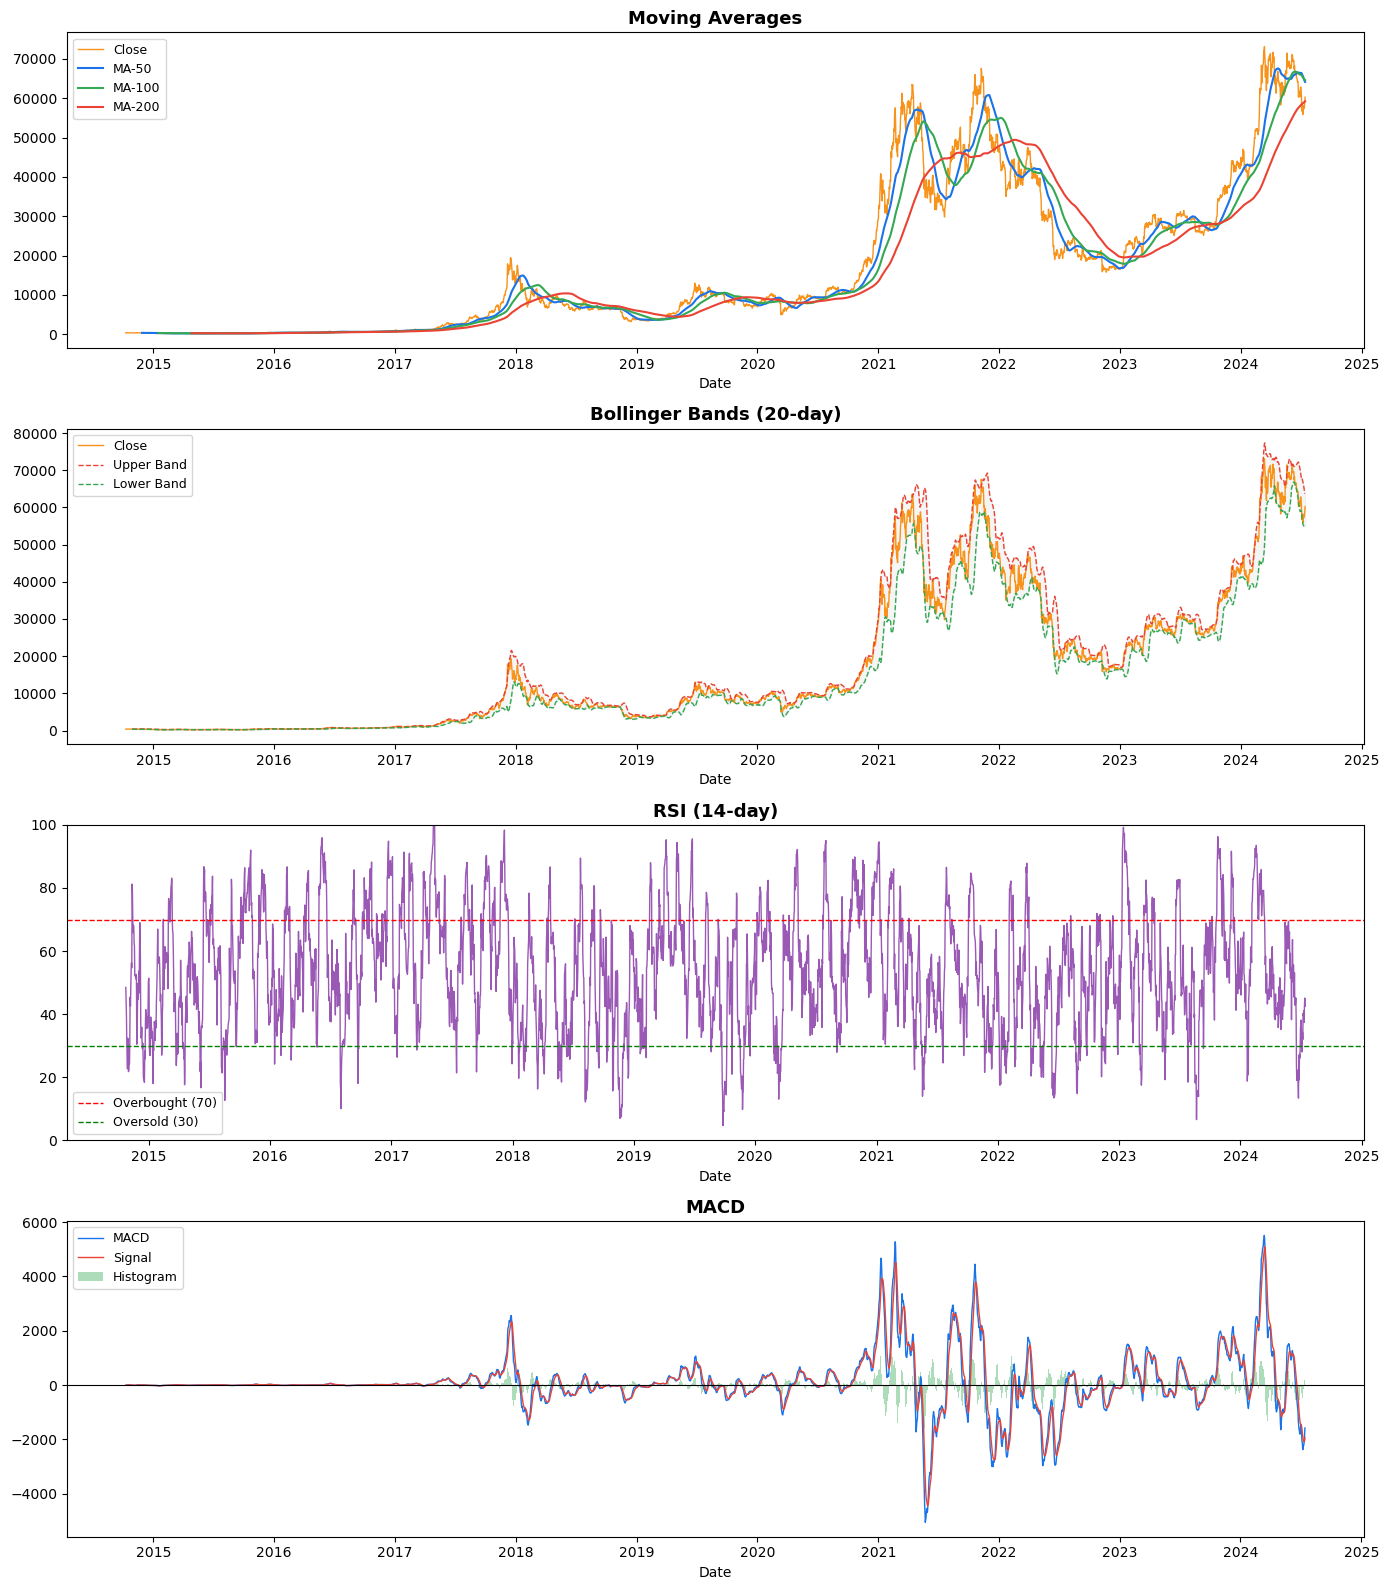

In [28]:
# ── Visualise Technical Indicators ──
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Moving Averages
axes[0].plot(df_feat.index, df_feat['Close'],   label='Close',  color='#F7931A', linewidth=1)
for ma, c in zip([50, 100, 200], ['#1A73E8','#34A853','#EA4335']):
    axes[0].plot(df_feat.index, df_feat[f'MA_{ma}'], label=f'MA-{ma}', color=c, linewidth=1.5)
axes[0].set_title('Moving Averages', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Bollinger Bands
axes[1].plot(df_feat.index, df_feat['Close'],    label='Close',      color='#F7931A', linewidth=1)
axes[1].plot(df_feat.index, df_feat['BB_Upper'], label='Upper Band',  color='#EA4335', linewidth=1, linestyle='--')
axes[1].plot(df_feat.index, df_feat['BB_Lower'], label='Lower Band',  color='#34A853', linewidth=1, linestyle='--')
axes[1].fill_between(df_feat.index, df_feat['BB_Lower'], df_feat['BB_Upper'], alpha=0.08, color='gray')
axes[1].set_title('Bollinger Bands (20-day)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

# RSI
axes[2].plot(df_feat.index, df_feat['RSI'], color='#9B59B6', linewidth=1)
axes[2].axhline(70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
axes[2].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (14-day)', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=9)

# MACD
axes[3].plot(df_feat.index, df_feat['MACD'],        label='MACD',   color='#1A73E8', linewidth=1)
axes[3].plot(df_feat.index, df_feat['MACD_Signal'], label='Signal', color='#EA4335', linewidth=1)
axes[3].bar(df_feat.index,  df_feat['MACD_Hist'],   label='Histogram', color='#34A853', alpha=0.4, width=1)
axes[3].axhline(0, color='black', linewidth=0.8)
axes[3].set_title('MACD', fontsize=13, fontweight='bold')
axes[3].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('nb2_01_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 : Train/Test

In [29]:
# ── Time Series (for ARIMA, SARIMA, Prophet) ──
series    = df['Close'].copy()
split_idx = int(len(series) * 0.8)
train_ts  = series.iloc[:split_idx]
test_ts   = series.iloc[split_idx:]

In [30]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [31]:
df_feat.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_14', 'MA_21',
       'MA_30', 'MA_50', 'MA_100', 'MA_200', 'EMA_9', 'EMA_12', 'EMA_26',
       'EMA_50', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Std',
       'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI', 'Stoch_K', 'Stoch_D', 'ATR',
       'Roll_Std_7', 'Roll_Min_7', 'Roll_Max_7', 'Roll_Skew_7', 'Roll_Std_14',
       'Roll_Min_14', 'Roll_Max_14', 'Roll_Skew_14', 'Roll_Std_30',
       'Roll_Min_30', 'Roll_Max_30', 'Roll_Skew_30', 'Daily_Return',
       'Log_Return', 'Price_Change', 'HL_Spread', 'OC_Spread', 'HL_Spread_Pct',
       'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Lag_14', 'Lag_21',
       'Lag_30', 'Vol_MA_7', 'Vol_MA_30', 'Vol_Change', 'Vol_Ratio',
       'DayOfWeek', 'DayOfMonth', 'DayOfYear', 'WeekOfYear', 'Month',
       'Quarter', 'Year', 'IsMonthEnd', 'IsQuarterEnd'],
      dtype='object')

In [32]:
# ── ML Feature Matrix ──
FEATURE_COLS = [
        'Open', 'High', 'Low', 'Volume', 'MA_7', 'MA_14', 'MA_21',
       'MA_30', 'MA_50', 'MA_100', 'MA_200', 'EMA_9', 'EMA_12', 'EMA_26',
       'EMA_50', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Std',
       'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI', 'Stoch_K', 'Stoch_D', 'ATR',
       'Roll_Std_7', 'Roll_Min_7', 'Roll_Max_7', 'Roll_Skew_7', 'Roll_Std_14',
       'Roll_Min_14', 'Roll_Max_14', 'Roll_Skew_14', 'Roll_Std_30',
       'Roll_Min_30', 'Roll_Max_30', 'Roll_Skew_30', 'Daily_Return',
       'Log_Return', 'Price_Change', 'HL_Spread', 'OC_Spread', 'HL_Spread_Pct',
       'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Lag_14', 'Lag_21',
       'Lag_30', 'Vol_MA_7', 'Vol_MA_30', 'Vol_Change', 'Vol_Ratio',
       'DayOfWeek', 'DayOfMonth', 'DayOfYear', 'WeekOfYear', 'Month',
       'Quarter', 'Year', 'IsMonthEnd', 'IsQuarterEnd'
]

In [33]:
df_ml  = df_feat[FEATURE_COLS + ['Close']].dropna()
X      = df_ml[FEATURE_COLS]
y      = df_ml['Close']
sp     = int(len(X) * 0.8)
X_train, X_test = X.iloc[:sp], X.iloc[sp:]
y_train, y_test = y.iloc[:sp], y.iloc[sp:]

In [34]:
# Save feature list for web app
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(FEATURE_COLS)}')

Train: 2693 | Test: 674 | Features: 66


## Section 5 : Model Training

### MODEL 1 - Arima

In [35]:
print('Running auto_arima...')
auto = pm.auto_arima(
    train_ts, d=1, seasonal=False,
    information_criterion='aic', stepwise=True,
    suppress_warnings=True, error_action='ignore'
)

Running auto_arima...


In [36]:
print(f'Best order: {auto.order}')

Best order: (2, 1, 2)


In [37]:
p, d, q = auto.order
arima_fit = ARIMA(train_ts, order=(p, d, q)).fit()
arima_pred = arima_fit.forecast(steps=len(test_ts))
arima_pred.index = test_ts.index

D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [38]:
# Save
arima_fit.save('models/arima_model.pkl')
arima_pred.to_csv('predictions/arima_pred.csv')
print(f' ARIMA({p},{d},{q}) trained & saved.')

 ARIMA(2,1,2) trained & saved.


### MODEL 2 - Sarima

In [39]:
print('Running auto_arima with seasonality (m=7)...')
sarima_auto = pm.auto_arima(
    train_ts, seasonal=True, m=7,
    max_p=3, max_q=3, max_P=2, max_Q=2, D=1, d=1,
    information_criterion='aic', stepwise=True,
    suppress_warnings=True, error_action='ignore'
)

Running auto_arima with seasonality (m=7)...


In [40]:
print(f'SARIMA order: {sarima_auto.order} × {sarima_auto.seasonal_order}')

SARIMA order: (2, 1, 0) × (2, 1, 0, 7)


In [41]:
sarima_fit  = SARIMAX(train_ts, order=sarima_auto.order,
                      seasonal_order=sarima_auto.seasonal_order).fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(test_ts))
sarima_pred.index = test_ts.index

D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Downloads\ANACONDASOFT\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [42]:
sarima_fit.save('models/sarima_model.pkl')
sarima_pred.to_csv('predictions/sarima_pred.csv')
print(' SARIMA trained & saved.')

 SARIMA trained & saved.


### MODEL 3 - Prophet

In [43]:
prophet_train = train_ts.reset_index().rename(columns={'Date':'ds','Close':'y'})

In [44]:
prophet_model = Prophet(
    yearly_seasonality=True, weekly_seasonality=True,
    daily_seasonality=False, changepoint_prior_scale=0.1,
    seasonality_mode='multiplicative'
)
prophet_model.fit(prophet_train)

16:40:14 - cmdstanpy - INFO - Chain [1] start processing
16:40:16 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
future        = prophet_model.make_future_dataframe(periods=len(test_ts))
prophet_fcst  = prophet_model.predict(future)
prophet_pred  = prophet_fcst['yhat'].iloc[-len(test_ts):].values
prophet_series = pd.Series(prophet_pred, index=test_ts.index, name='prophet')

In [46]:
joblib.dump(prophet_model, 'models/prophet_model.pkl')
prophet_series.to_csv('predictions/prophet_pred.csv')
print(' Prophet trained & saved.')

 Prophet trained & saved.


### MODEL 4 - XGBoost

In [47]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=3, gamma=0.1,
    random_state=42, n_jobs=-1, tree_method='hist'
)

In [48]:
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200
)

[0]	validation_0-rmse:27310.74978
[200]	validation_0-rmse:1529.77989
[400]	validation_0-rmse:1418.99593
[600]	validation_0-rmse:1414.70301
[800]	validation_0-rmse:1413.88872
[999]	validation_0-rmse:1413.35789


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.core.series.Series'>
(2693,)


In [50]:
print(type(y))
print(y.shape)
print(y.head())

<class 'pandas.core.series.Series'>
(3367,)
Date
2015-04-27    229.285995
2015-04-28    225.854996
2015-04-29    225.807999
2015-04-30    236.145004
2015-05-01    232.078995
Name: Close, dtype: float64


In [51]:
xgb_pred = xgb_model.predict(X_test)
xgb_series = pd.Series(xgb_pred, index=y_test.index, name='xgboost')

In [52]:
xgb_model.save_model('models/xgb_model.json')
xgb_series.to_csv('predictions/xgb_pred.csv')
print('XGBoost trained & saved.')

XGBoost trained & saved.


### MODEL 5 - Light GBM

In [53]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1
)

In [54]:
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=200)
    ]
)

[200]	valid_0's l2: 3.1067e+06


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,6
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [55]:
lgb_pred   = lgb_model.predict(X_test)
lgb_series = pd.Series(lgb_pred, index=y_test.index, name='lightgbm')

In [56]:
joblib.dump(lgb_model, 'models/lgb_model.pkl')
lgb_series.to_csv('predictions/lgb_pred.csv')
print('LightGBM trained & saved.')

LightGBM trained & saved.


### MODEL 6 - LSTM

In [57]:
# Scale
scaler       = MinMaxScaler(feature_range=(0, 1))
scaled       = scaler.fit_transform(series.values.reshape(-1, 1))
joblib.dump(scaler, 'models/lstm_scaler.pkl')

SEQ_LEN = 60

In [58]:
def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [59]:
X_seq, y_seq = make_sequences(scaled, SEQ_LEN)
sp_lstm = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:sp_lstm], X_seq[sp_lstm:]
y_tr, y_te = y_seq[:sp_lstm], y_seq[sp_lstm:]
X_tr = X_tr.reshape(-1, SEQ_LEN, 1)
X_te = X_te.reshape(-1, SEQ_LEN, 1)

print(f'LSTM Train: {X_tr.shape} | Test: {X_te.shape}')

LSTM Train: (2804, 60, 1) | Test: (702, 60, 1)


In [60]:
# Build Bidirectional LSTM
lstm_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 256)        │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,801 (893.75 KB)

 Trainable params: 228,801 (893.75 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1)
]

In [62]:
history = lstm_model.fit(
    X_tr, y_tr, epochs=100, batch_size=32,
    validation_split=0.1, callbacks=callbacks, verbose=1
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 0.0035 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 9.9175e-04 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 9.5718e-04 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 8.9653e-04 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 7.2266e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 5.4869e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 5.5184e-04 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 7.1836e-04 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 6.8915e-04 - val_loss: 0.0014 -

In [63]:
# Predict & inverse transform
lstm_pred_scaled = lstm_model.predict(X_te)
lstm_pred        = scaler.inverse_transform(lstm_pred_scaled).flatten()
y_te_actual      = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step  


In [65]:
lstm_sp    = int(len(series) * 0.8)
lstm_index = series.index[-len(lstm_pred):]
lstm_series = pd.Series(lstm_pred, index=lstm_index, name='lstm')

In [66]:
lstm_model.save('models/lstm_model.h5')
lstm_series.to_csv('predictions/lstm_pred.csv')
print('LSTM trained & saved.')

LSTM trained & saved.


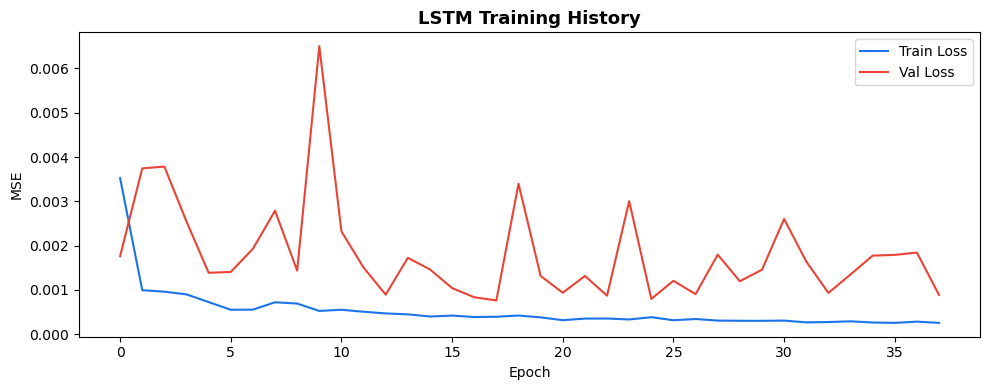

In [67]:
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='#1A73E8')
plt.plot(history.history['val_loss'], label='Val Loss',   color='#EA4335')
plt.title('LSTM Training History', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.savefig('nb2_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()